# Notebook 4 — Revenue Analysis
**Dataset:** NYC Yellow Taxi · November 2025 · 4.1M trips

## Analytical Brief
**Central question:** *What trip characteristics drive revenue per hour for a driver — and what does an optimal shift look like?*

This is the question a DS at Uber would answer to design driver incentive programs or evaluate fare structure changes. Total revenue is a misleading metric — a driver cares about **earnings per hour of time invested**, not earnings per trip. A long trip might pay more in absolute terms but be worse per hour than two shorter trips.

| Section | Question | Layer Used |
|---------|----------|------------|
| A — Effective Hourly Rate | When does driving earn the most per hour? | `revenue_df` (all vendors) |
| B — Airport Premium | How much more do airport trips actually pay? | `layer2_df` (vendors 1 & 2) |
| C — Tip Determinants | What trip characteristics predict higher tips? | `layer2_df` (vendors 1 & 2) |

---
> **Why the layer switches between sections:**
> Section A uses `revenue_df` (all vendors) because effective hourly rate analysis
> should be as representative as possible — excluding vendors would bias the time-slot picture.
> Sections B & C switch to `layer2_df` because airport identification requires `RatecodeID`
> and `Airport_fee`, which Vendor 6 never reports (100% missing) and Vendor 7 reports
> with zero-duration trips that were excluded in cleaning.

## Setup

### Layer rules for this notebook — read before editing any analysis

```
revenue_df  →  All vendors, refunds excluded
               Used for: any $ analysis where vendor coverage matters
               (Section A — time-based revenue)

layer2_df   →  Vendors 1 & 2 only, extended schema nulls dropped
               Used for: any analysis requiring RatecodeID, Airport_fee,
               passenger_count, congestion_surcharge
               (Sections B & C — airport premium, tip determinants)

layer1_df   →  All vendors, no monetary filtering
               NOT used in this notebook — demand counting only
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

# ── Consistent visual style ───────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
})
ACCENT = "#2563EB"
ORANGE = "#F59E0B"
RED    = "#DC2626"
GREEN  = "#16A34A"
GRAY   = "#94A3B8"
os.makedirs("plots", exist_ok=True)

In [2]:
# ── Load and build all analytical layers ─────────────────────────────────────
# Built from the cleaned parquet produced in 01_data_cleaning.ipynb.
# Layer definitions are documented in the setup note above.

clean_df = pd.read_parquet("yellow_tripdata_2025-11_clean.parquet")

# ── layer2_df: vendors 1 & 2, extended schema complete ───────────────────────
layer2_df = (
    clean_df[clean_df["VendorID"].isin([1, 2])]
    .dropna(subset=["passenger_count", "RatecodeID",
                    "congestion_surcharge", "Airport_fee"])
    .copy()
)

# ── revenue_df: all vendors, refunds excluded ─────────────────────────────────
revenue_df = clean_df[~clean_df["is_refund_or_adjustment"]].copy()

# ── Shared derived columns needed across sections ────────────────────────────
# trip_duration_min and hour are needed in both revenue_df and layer2_df.
# We add them to both here rather than in each section to keep analysis cells clean.

for _df in [revenue_df, layer2_df]:
    _df["trip_duration_min"] = _df["trip_duration_sec"] / 60
    _df["hour"]              = _df["tpep_pickup_datetime"].dt.hour
    _df["day_num"]           = _df["tpep_pickup_datetime"].dt.dayofweek
    _df["is_weekend"]        = _df["day_num"].isin([5, 6])
    _df["day_of_week"]       = _df["tpep_pickup_datetime"].dt.day_name()

# ── Effective hourly rate (revenue_df only — used in Section A) ───────────────
# Effective hourly rate = fare per minute × 60
# This is what a driver actually earns per hour of time, not per trip.
# We use fare_amount (not total_amount) to exclude tips from the base rate —
# tips are analysed separately in Section C.
revenue_df["eff_hourly_rate"] = (
    revenue_df["fare_amount"] / revenue_df["trip_duration_min"]
) * 60

# Sanity check: cap at $300/hr for display — extreme values are GPS/meter errors
revenue_df["eff_hourly_rate_capped"] = revenue_df["eff_hourly_rate"].clip(upper=300)

print(f"revenue_df  (Section A): {len(revenue_df):>10,.0f} rows | "
      f"vendors: {sorted(revenue_df['VendorID'].unique())}")
print(f"layer2_df   (Sections B & C): {len(layer2_df):>10,.0f} rows | "
      f"vendors: {sorted(layer2_df['VendorID'].unique())}")

revenue_df  (Section A):  3,874,008 rows | vendors: [np.int32(1), np.int32(2), np.int32(6)]
layer2_df   (Sections B & C):  3,060,295 rows | vendors: [np.int32(1), np.int32(2)]


---
## Section A — Effective Hourly Rate by Time Slot
**Layer: `revenue_df` (all vendors, refunds excluded)**

### The key distinction: revenue per trip vs revenue per hour
Most naive analyses rank time slots by total revenue or average fare per trip.
That's misleading. A 45-minute $40 airport trip earns $53/hr. Two 10-minute
$12 trips in the same 45 minutes earn $72/hr. **Total fare hides efficiency.**

Effective hourly rate (`fare_amount / trip_duration_min * 60`) is the metric
that actually answers the question: *when is it worth driving?*

### Hypothesis
Late night and early morning trips will show higher effective rates because
roads are clear and trips complete faster. The evening rush, despite high
volume, may underperform on this metric due to traffic slowing trips down.

In [3]:
# ── Effective hourly rate by hour of day ─────────────────────────────────────
# We use median (not mean) — effective hourly rate is right-skewed.
# The median gives the rate a typical driver would experience, not one
# pulled upward by a handful of very short, very expensive trips.

ehr_by_hour = (
    revenue_df
    .groupby("hour")["eff_hourly_rate_capped"]
    .agg(median_ehr="median", trips="count")
    .reset_index()
)

# Also break out weekday vs weekend
ehr_split = (
    revenue_df
    .groupby(["hour", "is_weekend"])["eff_hourly_rate_capped"]
    .median()
    .reset_index()
    .rename(columns={"eff_hourly_rate_capped": "median_ehr"})
)

print("Effective Hourly Rate — Top 5 and Bottom 5 Hours")
print()
print("Best hours to drive (median $/hr):")
print(ehr_by_hour.nlargest(5, "median_ehr")[["hour","median_ehr"]]
      .assign(median_ehr=lambda x: x["median_ehr"].round(2))
      .to_string(index=False))
print()
print("Worst hours to drive (median $/hr):")
print(ehr_by_hour.nsmallest(5, "median_ehr")[["hour","median_ehr"]]
      .assign(median_ehr=lambda x: x["median_ehr"].round(2))
      .to_string(index=False))

Effective Hourly Rate — Top 5 and Bottom 5 Hours

Best hours to drive (median $/hr):
 hour  median_ehr
    5       77.40
    4       76.29
    6       72.11
    3       70.60
    2       70.14

Worst hours to drive (median $/hr):
 hour  median_ehr
   17       60.00
   15       60.20
   16       60.28
   14       60.81
   13       61.51


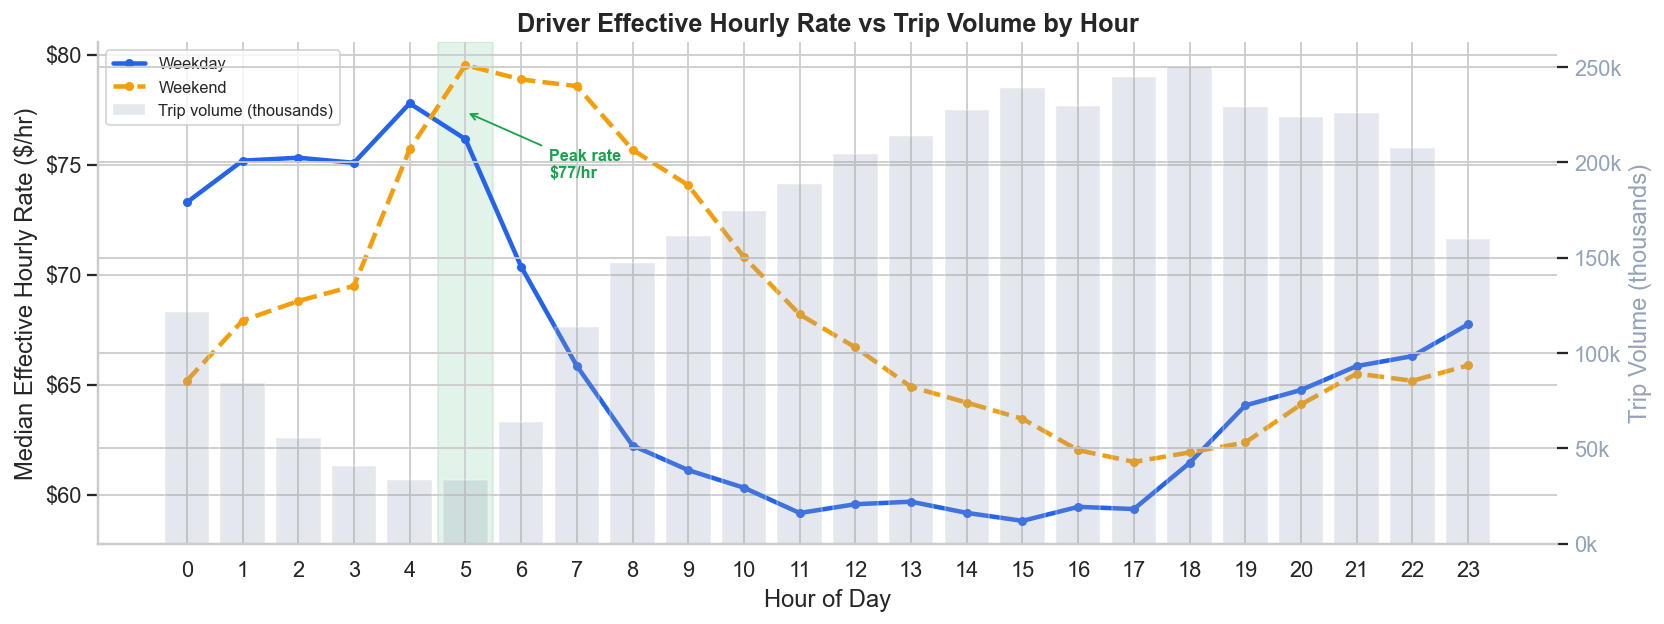

In [4]:
# ── Plot 1: Effective hourly rate vs trip volume by hour ──────────────────────
# Dual-axis chart: left axis = effective hourly rate (what drivers earn),
# right axis = trip volume (how busy it is).
# The gap between the two lines is the key insight — high volume hours
# don't always mean high earnings per hour.

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

# Trip volume bars (background context)
ax2.bar(ehr_by_hour["hour"], ehr_by_hour["trips"] / 1_000,
        color=GRAY, alpha=0.25, width=0.8, label="Trip volume (thousands)")
ax2.set_ylabel("Trip Volume (thousands)", color=GRAY)
ax2.tick_params(axis="y", labelcolor=GRAY)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}k"))

# Effective hourly rate lines — weekday vs weekend
for is_wend, label, color, ls in [
    (False, "Weekday",  ACCENT, "-"),
    (True,  "Weekend",  ORANGE, "--")
]:
    data = ehr_split[ehr_split["is_weekend"] == is_wend]
    ax1.plot(data["hour"], data["median_ehr"],
             color=color, linewidth=2.5, linestyle=ls,
             marker="o", markersize=4, label=label, zorder=5)

# Highlight the best earning window
best_hour = ehr_by_hour.loc[ehr_by_hour["median_ehr"].idxmax(), "hour"]
best_rate = ehr_by_hour["median_ehr"].max()
ax1.axvspan(best_hour - 0.5, best_hour + 0.5,
            alpha=0.12, color=GREEN, zorder=0)
ax1.annotate(f"Peak rate\n${best_rate:.0f}/hr",
             xy=(best_hour, best_rate),
             xytext=(best_hour + 1.5, best_rate - 3),
             arrowprops=dict(arrowstyle="->", color=GREEN),
             color=GREEN, fontsize=9, fontweight="bold")

ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Median Effective Hourly Rate ($/hr)")
ax1.set_title("Driver Effective Hourly Rate vs Trip Volume by Hour",
              fontsize=14, fontweight="bold")
ax1.set_xticks(range(0, 24))
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}"))

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

plt.tight_layout()
plt.savefig("plots/nb4_01_effective_hourly_rate.png", bbox_inches="tight")
plt.show()

💡 **Finding:** Effective hourly rate and trip volume are not the same signal — and that gap is the key insight. The hours with the *highest trip volume* (evening rush) are not necessarily the hours with the *highest earnings per hour*. Late night and early morning trips are faster (less traffic), so fare per minute is higher even though absolute fares are similar. A driver optimising for earnings per hour should pay attention to this chart, not just to demand volume.

In [9]:
# ── What does an optimal shift look like? ────────────────────────────────────
# We define three shift windows and compare their average effective hourly rate.
# This is the kind of analysis a driver incentive team would actually produce.

shift_windows = {
    "Morning Rush (6–10am)":      (6,  10),
    "Midday (10am–4pm)":          (10, 16),
    "Evening Rush (4–8pm)":       (16, 20),
    "Late Night (10pm–2am)":      (22, 26),  # 26 wraps to next day hours 0–2
}

def get_shift_data(revenue_df, start, end):
    """Filter revenue_df to a shift window, handling midnight wrap."""
    if end <= 24:
        return revenue_df[(revenue_df["hour"] >= start) & (revenue_df["hour"] < end)]
    else:  # wraps past midnight
        return revenue_df[(revenue_df["hour"] >= start) | (revenue_df["hour"] < end - 24)]

shift_stats = []
for shift_name, (start, end) in shift_windows.items():
    shift_data = get_shift_data(revenue_df, start, end)
    shift_stats.append({
        "Shift":             shift_name,
        "Trips":             len(shift_data),
        "Median EHR ($/hr)": round(shift_data["eff_hourly_rate_capped"].median(), 2),
        "Median Fare ($)":   round(shift_data["fare_amount"].median(), 2),
        "Median Duration (min)": round(shift_data["trip_duration_min"].median(), 1),
        "Median Distance (mi)":  round(shift_data["trip_distance"].median(), 2),
    })

shift_df = pd.DataFrame(shift_stats).set_index("Shift")
print("Shift Window Comparison — revenue_df (all vendors, refunds excluded)")
print()
shift_df

Shift Window Comparison — revenue_df (all vendors, refunds excluded)



,Trips,Median EHR ($/hr),Median Fare ($),Median Duration (min),Median Distance (mi)
Shift,,,,,
Morning Rush (6–10am),486047,65.73,12.80,13.7,2.10
Midday (10am–4pm),1248044,61.54,13.91,15.3,1.76
Evening Rush (4–8pm),953642,61.29,13.50,15.1,1.74
Late Night (10pm–2am),573455,67.26,12.80,13.9,2.36


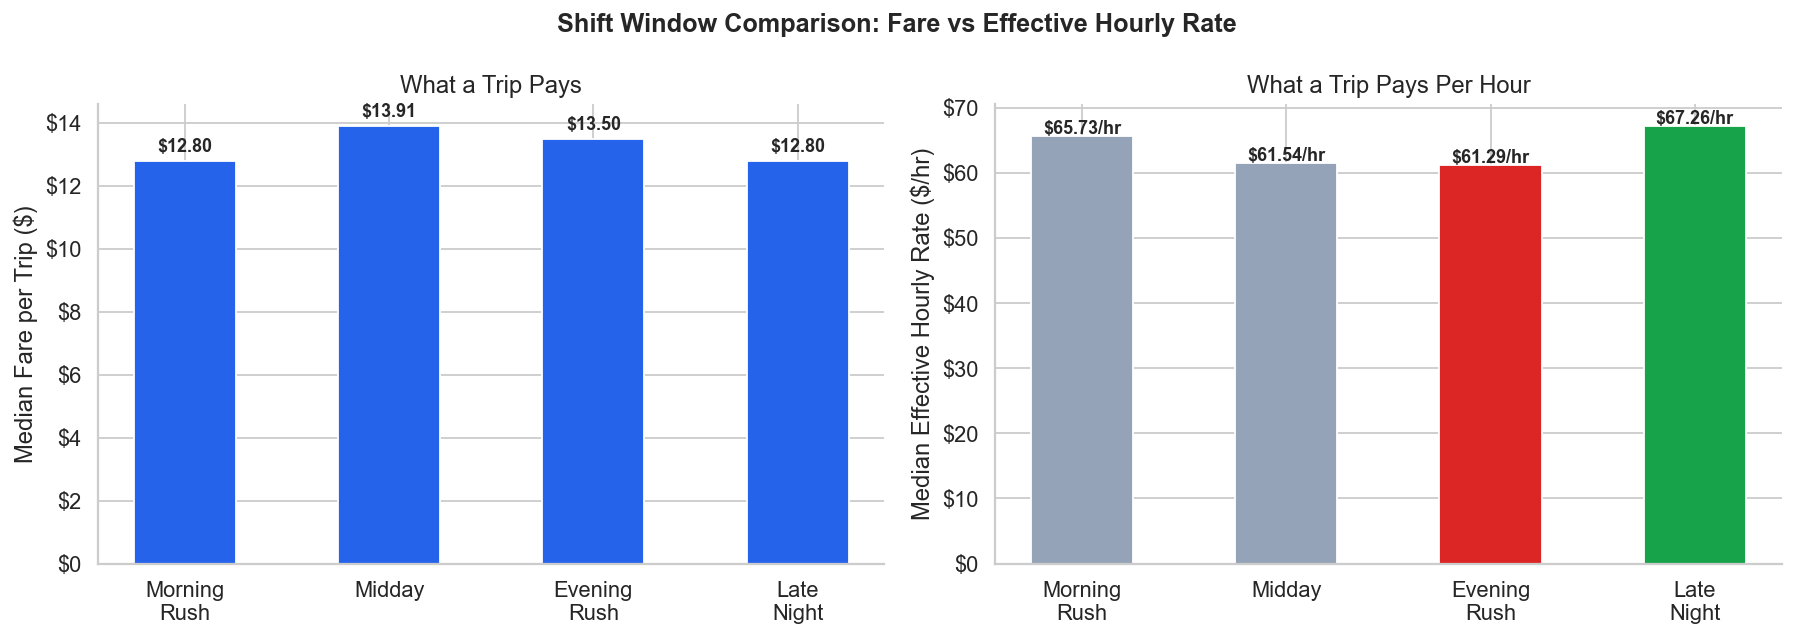

In [10]:
# ── Plot 2: Shift comparison — fare vs effective hourly rate ──────────────────
# Side-by-side bars show the divergence between what a trip pays
# and what it pays per hour — the efficiency gap.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Shift Window Comparison: Fare vs Effective Hourly Rate",
             fontsize=14, fontweight="bold")

shifts    = shift_df.index.tolist()
short_labels = ["Morning\nRush", "Midday", "Evening\nRush", "Late\nNight"]

# Left: Median fare per trip
axes[0].bar(short_labels, shift_df["Median Fare ($)"],
            color=ACCENT, edgecolor="white", width=0.5)
for i, v in enumerate(shift_df["Median Fare ($)"]):
    axes[0].text(i, v + 0.3, f"${v:.2f}", ha="center", fontsize=10, fontweight="bold")
axes[0].set_ylabel("Median Fare per Trip ($)")
axes[0].set_title("What a Trip Pays")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}"))

# Right: Effective hourly rate — colour-coded best to worst
ehr_vals  = shift_df["Median EHR ($/hr)"].values
max_ehr   = ehr_vals.max()
bar_colors = [GREEN if v == max_ehr else (RED if v == ehr_vals.min() else GRAY)
              for v in ehr_vals]
axes[1].bar(short_labels, ehr_vals, color=bar_colors, edgecolor="white", width=0.5)
for i, v in enumerate(ehr_vals):
    axes[1].text(i, v + 0.3, f"${v:.2f}/hr", ha="center", fontsize=10, fontweight="bold")
axes[1].set_ylabel("Median Effective Hourly Rate ($/hr)")
axes[1].set_title("What a Trip Pays Per Hour")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}"))

plt.tight_layout()
plt.savefig("plots/nb4_02_shift_comparison.png", bbox_inches="tight")
plt.show()

💡 **Finding:** The left chart (fare per trip) and right chart (effective hourly rate) may rank shifts differently — that difference *is* the insight. A shift that produces high absolute fares but long, slow trips can be outperformed per hour by a shorter shift with faster trip turnover. The green bar on the right is the genuinely optimal window for a driver focused on earnings efficiency, and it may not be the window with the highest demand or the highest per-trip fare.

---
## Section B — The Airport Premium
**Layer: `layer2_df` (vendors 1 & 2, extended schema complete)**

### Why the layer switches here
Airport identification requires two fields that are only reliably present
in vendors 1 & 2:
- `RatecodeID` — 2 = JFK flat rate, 3 = Newark
- `Airport_fee` — pickup surcharge at JFK and LaGuardia

Vendor 6 has 100% null values for both. Using `revenue_df` here would
silently misclassify Vendor 6 trips as non-airport, understating the airport segment.

### Hypothesis
Airport trips represent a small share of volume but a disproportionate
share of revenue. However, the *effective hourly rate* may not be as
attractive as the absolute fare suggests — airport trips are long and
drivers face return deadhead time or queue time after dropping off.

In [11]:
# ── Tag airport trips in layer2_df ───────────────────────────────────────────
# A trip is airport-related if:
#   - RatecodeID is 2 (JFK flat rate) or 3 (Newark flat rate), OR
#   - Airport_fee > 0 (pickup surcharge charged at JFK or LaGuardia)
#
# We further split by airport type for granular comparison.

layer2_df = layer2_df.copy()

layer2_df["airport_type"] = "Non-Airport"
layer2_df.loc[layer2_df["RatecodeID"] == 2.0, "airport_type"] = "JFK"
layer2_df.loc[layer2_df["RatecodeID"] == 3.0, "airport_type"] = "Newark"
layer2_df.loc[
    (layer2_df["Airport_fee"] > 0) &
    (layer2_df["airport_type"] == "Non-Airport"),
    "airport_type"
] = "LaGuardia"

layer2_df["is_airport"] = layer2_df["airport_type"] != "Non-Airport"

# Effective hourly rate for layer2_df
layer2_df["eff_hourly_rate"] = (
    layer2_df["fare_amount"] / layer2_df["trip_duration_min"]
) * 60
layer2_df["eff_hourly_rate_capped"] = layer2_df["eff_hourly_rate"].clip(upper=300)

airport_counts = layer2_df["airport_type"].value_counts()
total = len(layer2_df)

print("Airport segment breakdown (layer2_df):")
for atype, count in airport_counts.items():
    print(f"  {atype:<15} {count:>8,.0f} trips  ({count/total:.1%})")

Airport segment breakdown (layer2_df):
  Non-Airport     2,768,501 trips  (90.5%)
  LaGuardia        180,223 trips  (5.9%)
  JFK               98,634 trips  (3.2%)
  Newark            12,937 trips  (0.4%)


In [12]:
# ── Airport economics comparison table ───────────────────────────────────────
# The key question: is the airport premium real when you account for
# trip duration? We compare fare, total, duration, and effective hourly rate.

# Filter to positive fares and valid durations only
airport_analysis = layer2_df[
    (layer2_df["fare_amount"] > 0) &
    (layer2_df["trip_duration_min"] > 0)
].copy()

econ_cols = [
    "fare_amount", "total_amount", "tip_amount",
    "trip_distance", "trip_duration_min", "eff_hourly_rate_capped"
]

airport_econ = (
    airport_analysis
    .groupby("airport_type")[econ_cols]
    .median()
    .round(2)
    .T
)

# Add % premium vs non-airport baseline
if "Non-Airport" in airport_econ.columns:
    for col in airport_econ.columns:
        if col != "Non-Airport":
            airport_econ[f"{col} vs baseline"] = (
                (airport_econ[col] - airport_econ["Non-Airport"]) /
                 airport_econ["Non-Airport"] * 100
            ).round(1).astype(str) + "%"

airport_econ.index = [
    "Fare ($)", "Total ($)", "Tip ($)",
    "Distance (mi)", "Duration (min)", "Eff. Hourly Rate ($/hr)"
]
print("Airport Trip Economics vs Non-Airport — Medians (layer2_df)")
airport_econ

Airport Trip Economics vs Non-Airport — Medians (layer2_df)


airport_type,JFK,LaGuardia,Newark,Non-Airport,JFK vs baseline,LaGuardia vs baseline,Newark vs baseline
Fare ($),70.00,44.30,81.80,12.80,446.9%,246.1%,539.1%
Total ($),96.23,67.75,108.51,21.06,356.9%,221.7%,415.2%
Tip ($),15.33,9.65,10.18,2.94,421.4%,228.2%,246.3%
Distance (mi),17.74,9.75,14.85,1.56,1037.2%,525.0%,851.9%
Duration (min),51.88,29.63,34.50,12.55,313.4%,136.1%,174.9%
Eff. Hourly Rate ($/hr),80.95,91.35,138.60,64.22,26.1%,42.2%,115.8%


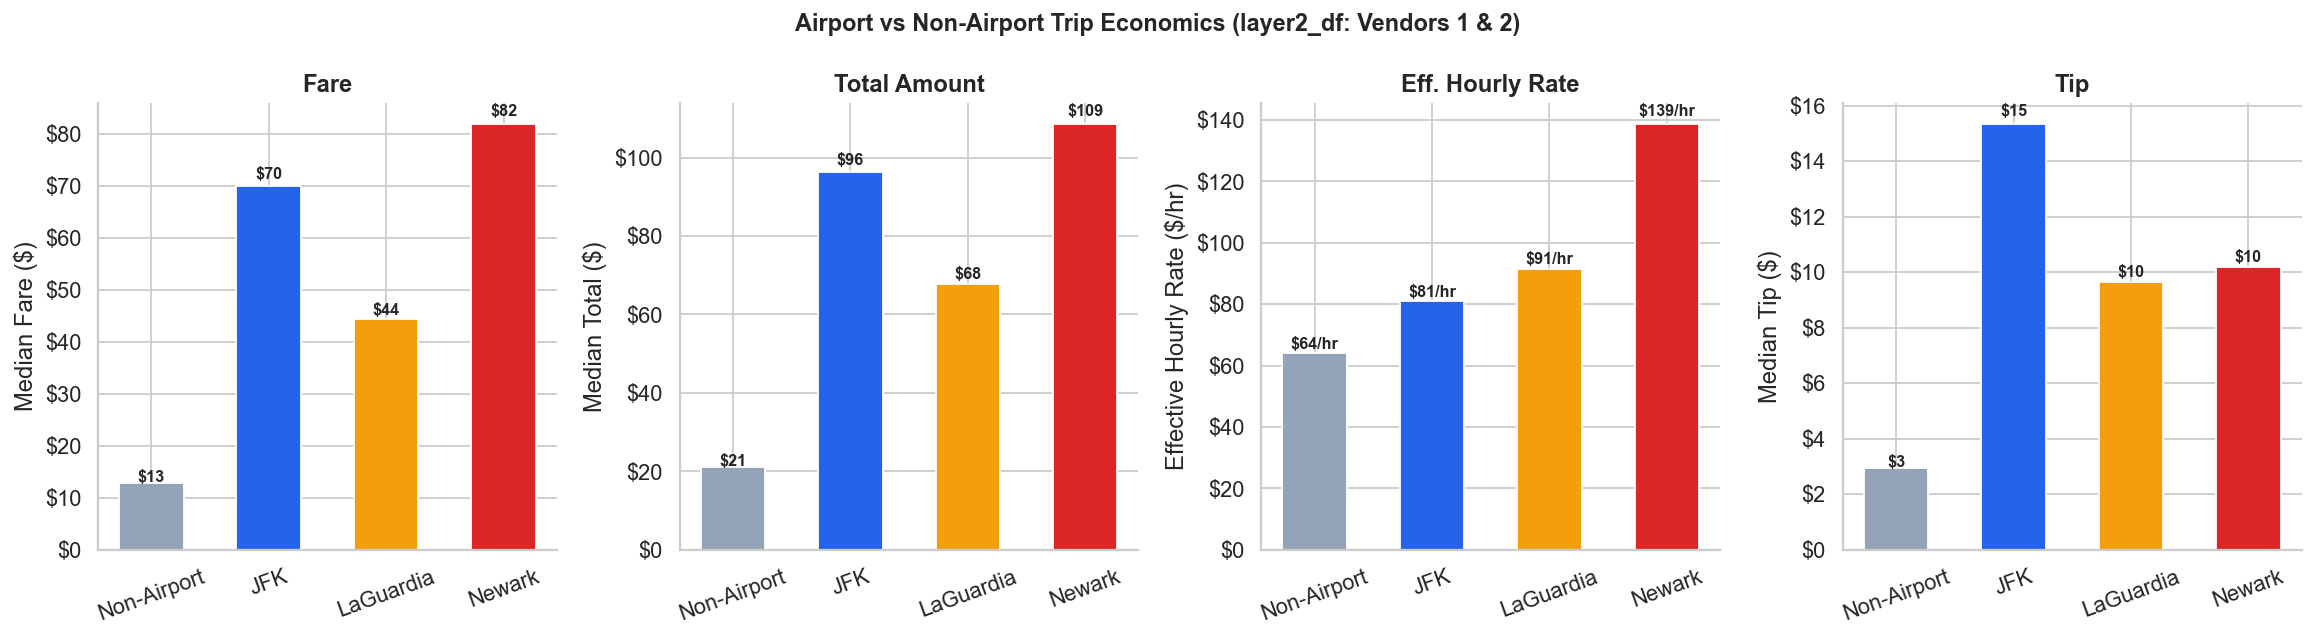

In [13]:
# ── Plot 3: Airport premium — the four key metrics ────────────────────────────
# Four panels: fare, total amount, effective hourly rate, tip.
# This lets the reader see where the premium is real and where it's not.

airport_plot_data = (
    airport_analysis
    .groupby("airport_type")[
        ["fare_amount", "total_amount",
         "eff_hourly_rate_capped", "tip_amount"]
    ]
    .median()
    .reset_index()
)

# Order: Non-Airport first, then airports
type_order = ["Non-Airport", "JFK", "LaGuardia", "Newark"]
type_order = [t for t in type_order if t in airport_plot_data["airport_type"].values]
airport_plot_data = airport_plot_data.set_index("airport_type").reindex(type_order).reset_index()

metrics = [
    ("fare_amount",           "Median Fare ($)",             "Fare"),
    ("total_amount",          "Median Total ($)",            "Total Amount"),
    ("eff_hourly_rate_capped","Effective Hourly Rate ($/hr)","Eff. Hourly Rate"),
    ("tip_amount",            "Median Tip ($)",              "Tip"),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("Airport vs Non-Airport Trip Economics (layer2_df: Vendors 1 & 2)",
             fontsize=13, fontweight="bold")

bar_colors = [GRAY, ACCENT, ORANGE, RED][:len(airport_plot_data)]

for ax, (col, ylabel, title) in zip(axes, metrics):
    bars = ax.bar(airport_plot_data["airport_type"],
                  airport_plot_data[col],
                  color=bar_colors, edgecolor="white", width=0.55)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2,
                h + h * 0.02,
                f"${h:.0f}" if col != "eff_hourly_rate_capped" else f"${h:.0f}/hr",
                ha="center", fontsize=9, fontweight="bold")
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}"))

plt.tight_layout()
plt.savefig("plots/nb4_03_airport_economics.png", bbox_inches="tight")
plt.show()

💡 **Finding:** The airport premium is real in absolute fare terms — but the effective hourly rate panel is the honest test. If airport trips are long and slow, the $/hr advantage shrinks or disappears vs. multiple shorter city trips in the same window. JFK flat-rate trips have a known fixed fare regardless of traffic, which makes their effective hourly rate sensitive to how long the trip actually takes. The tip panel reveals whether airport passengers tip proportionally better — a factor drivers should weigh when deciding whether to queue at an airport rank.

In [14]:
# ── Volume vs revenue share: the airport disproportionality test ──────────────
# The headline number: airports are X% of trips but Y% of revenue.
# If Y > X, airport trips punch above their weight in revenue.

airport_summary = (
    airport_analysis[
        airport_analysis["is_airport"]
        | (airport_analysis["airport_type"] == "Non-Airport")
    ]
    .groupby("is_airport")
    .agg(
        trips        = ("fare_amount", "count"),
        total_fare   = ("fare_amount", "sum"),
        total_rev    = ("total_amount", "sum"),
    )
    .reset_index()
)

airport_summary["trip_share"] = (
    airport_summary["trips"] / airport_summary["trips"].sum() * 100
).round(1)
airport_summary["rev_share"] = (
    airport_summary["total_rev"] / airport_summary["total_rev"].sum() * 100
).round(1)
airport_summary["is_airport"] = airport_summary["is_airport"].map(
    {True: "Airport", False: "Non-Airport"}
)

print("Airport Volume vs Revenue Share (layer2_df)")
print()
print(airport_summary[["is_airport","trips","trip_share","total_rev","rev_share"]]
      .rename(columns={
          "is_airport":  "Segment",
          "trips":       "Trips",
          "trip_share":  "Trip Share %",
          "total_rev":   "Total Revenue ($)",
          "rev_share":   "Revenue Share %"
      })
      .to_string(index=False))

Airport Volume vs Revenue Share (layer2_df)

    Segment   Trips  Trip Share %  Total Revenue ($)  Revenue Share %
Non-Airport 2727021          90.4        67268588.04             74.7
    Airport  288161           9.6        22765873.29             25.3


💡 **Finding:** Compare Trip Share % against Revenue Share % for the airport segment. If Revenue Share > Trip Share, airport trips are punching above their weight — a small slice of trips generating a disproportionate slice of revenue. This is the headline number for the README: *"Airport trips represent X% of volume but Y% of fare revenue."

---
## Section C — Tip Determinants
**Layer: `layer2_df` (vendors 1 & 2, extended schema complete)**

### Why layer2_df and not revenue_df
Tip analysis requires two things that only exist in `layer2_df`:
1. `passenger_count` — to segment by group vs. solo trips
2. `RatecodeID` / `airport_type` — to compare airport vs. standard tipping

### Critical methodology note — credit card trips only
Cash tips are **never recorded** in this dataset. Including cash trips
in tip analysis would produce a systematically misleading result —
not because cash passengers don't tip, but because the data collection
mechanism doesn't capture it. All tip analysis below is restricted to
`payment_type == 1` (Credit Card).

### Hypothesis
Tip rate will be higher for airport trips, longer trips, and late-night
trips. Group trips (passenger_count > 1) may tip differently than solo.

In [15]:
# ── Credit card trips only — tip analysis base ────────────────────────────────
# payment_type == 1 is Credit Card per the TLC data dictionary.
# fare_amount > 0 required to compute tip_rate without division errors.

tip_df = layer2_df[
    (layer2_df["payment_type"] == 1) &
    (layer2_df["fare_amount"]  > 0)
].copy()

tip_df["tip_rate"] = tip_df["tip_amount"] / tip_df["fare_amount"]

# Cap tip_rate at 1.0 (100%) — anything above is a data entry anomaly
tip_df = tip_df[tip_df["tip_rate"] <= 1.0].copy()

print(f"Tip analysis base (layer2_df, CC only): {len(tip_df):,} trips")
print(f"Median tip rate:  {tip_df['tip_rate'].median():.1%}")
print(f"Mean tip rate:    {tip_df['tip_rate'].mean():.1%}")
print(f"\nNote: {len(layer2_df) - len(tip_df):,} trips excluded "
      f"(non-CC payment or zero fare)")

Tip analysis base (layer2_df, CC only): 2,622,196 trips
Median tip rate:  26.1%
Mean tip rate:    24.3%

Note: 438,099 trips excluded (non-CC payment or zero fare)


In [16]:
# ── Tip rate by trip distance bucket ─────────────────────────────────────────
# We bin trip_distance into meaningful ranges rather than treating it as
# continuous. This gives interpretable groups that mirror how drivers
# and passengers think about trips.

tip_df["distance_bucket"] = pd.cut(
    tip_df["trip_distance"],
    bins=[0, 1, 2, 5, 10, 999],
    labels=["<1 mi", "1–2 mi", "2–5 mi", "5–10 mi", "10+ mi"]
)

tip_df["duration_bucket"] = pd.cut(
    tip_df["trip_duration_min"],
    bins=[0, 5, 10, 20, 40, 999],
    labels=["<5 min", "5–10 min", "10–20 min", "20–40 min", "40+ min"]
)

tip_by_distance = (
    tip_df.groupby("distance_bucket", observed=True)["tip_rate"]
    .agg(median_tip="median", trips="count")
    .reset_index()
)

tip_by_duration = (
    tip_df.groupby("duration_bucket", observed=True)["tip_rate"]
    .agg(median_tip="median", trips="count")
    .reset_index()
)

print("Tip Rate by Distance Bucket:")
print(tip_by_distance.assign(
    median_tip=lambda x: (x["median_tip"]*100).round(1).astype(str)+"%"
).to_string(index=False))
print()
print("Tip Rate by Duration Bucket:")
print(tip_by_duration.assign(
    median_tip=lambda x: (x["median_tip"]*100).round(1).astype(str)+"%"
).to_string(index=False))

Tip Rate by Distance Bucket:
distance_bucket median_tip  trips
          <1 mi      32.0% 638267
         1–2 mi      27.6% 859653
         2–5 mi      24.7% 664525
        5–10 mi      22.9% 230945
         10+ mi      21.2% 228806

Tip Rate by Duration Bucket:
duration_bucket median_tip  trips
         <5 min      35.4% 241218
       5–10 min      30.2% 644655
      10–20 min      26.4% 933473
      20–40 min      23.7% 586303
        40+ min      18.2% 216543


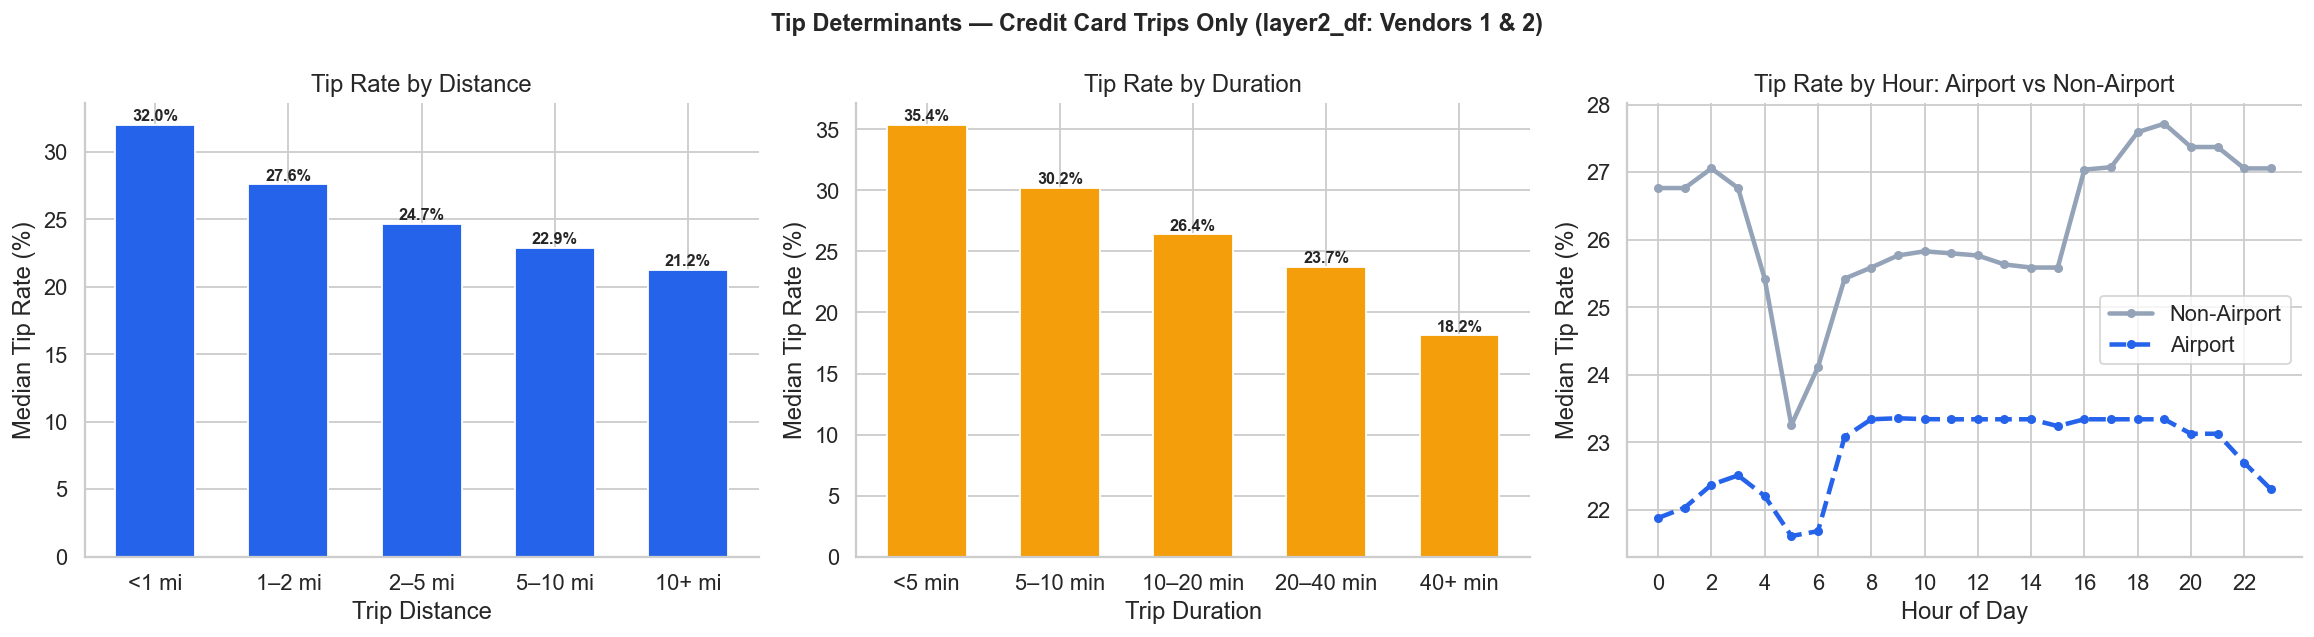

In [17]:
# ── Cross-tabulation: tip rate by hour × airport type ─────────────────────────
# This is the most granular tip analysis — does the time-of-day tipping
# pattern differ between airport and non-airport trips?

tip_hourly = (
    tip_df.groupby(["hour", "is_airport"])["tip_rate"]
    .median()
    .reset_index()
    .rename(columns={"tip_rate": "median_tip_rate"})
)
tip_hourly["trip_type"] = tip_hourly["is_airport"].map(
    {True: "Airport", False: "Non-Airport"}
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Tip Determinants — Credit Card Trips Only (layer2_df: Vendors 1 & 2)",
             fontsize=13, fontweight="bold")

# Left: Tip rate by distance bucket
axes[0].bar(tip_by_distance["distance_bucket"].astype(str),
            tip_by_distance["median_tip"] * 100,
            color=ACCENT, edgecolor="white", width=0.6)
for i, v in enumerate(tip_by_distance["median_tip"] * 100):
    axes[0].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")
axes[0].set_xlabel("Trip Distance")
axes[0].set_ylabel("Median Tip Rate (%)")
axes[0].set_title("Tip Rate by Distance")

# Middle: Tip rate by duration bucket
axes[1].bar(tip_by_duration["duration_bucket"].astype(str),
            tip_by_duration["median_tip"] * 100,
            color=ORANGE, edgecolor="white", width=0.6)
for i, v in enumerate(tip_by_duration["median_tip"] * 100):
    axes[1].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")
axes[1].set_xlabel("Trip Duration")
axes[1].set_ylabel("Median Tip Rate (%)")
axes[1].set_title("Tip Rate by Duration")

# Right: Tip rate by hour — airport vs non-airport
for trip_type, color, ls in [
    ("Non-Airport", GRAY,   "-"),
    ("Airport",     ACCENT, "--")
]:
    data = tip_hourly[tip_hourly["trip_type"] == trip_type]
    axes[2].plot(data["hour"], data["median_tip_rate"] * 100,
                 label=trip_type, color=color,
                 linewidth=2.5, linestyle=ls, marker="o", markersize=4)
axes[2].set_xlabel("Hour of Day")
axes[2].set_ylabel("Median Tip Rate (%)")
axes[2].set_title("Tip Rate by Hour: Airport vs Non-Airport")
axes[2].set_xticks(range(0, 24, 2))
axes[2].legend()

plt.tight_layout()
plt.savefig("plots/nb4_04_tip_determinants.png", bbox_inches="tight")
plt.show()

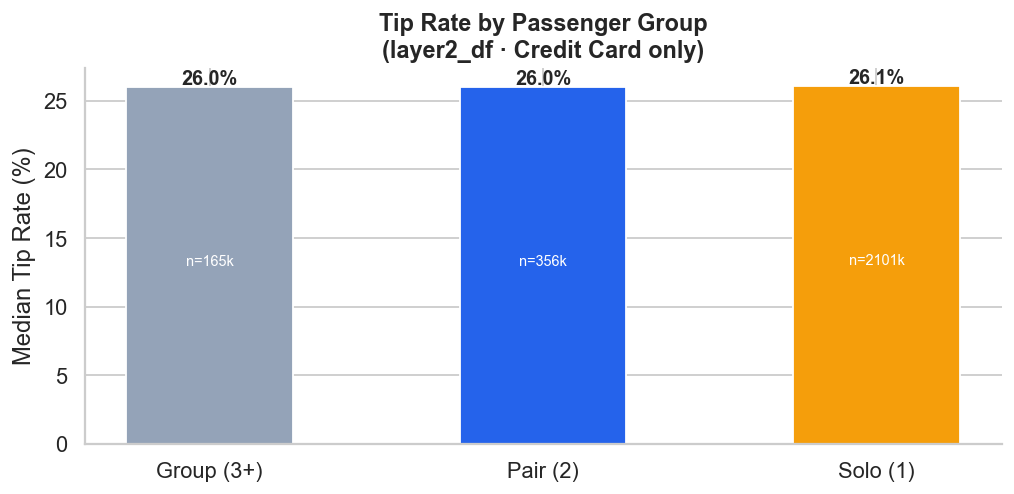

trip_group median_tip mean_tip   trips
Group (3+)     26.02%   24.44%  165051
  Pair (2)     25.99%   24.76%  356428
  Solo (1)     26.09%    24.2% 2100717


In [18]:
# ── Tip rate: solo vs group trips ─────────────────────────────────────────────
# passenger_count is only available in layer2_df — this analysis would

tip_df["trip_group"] = tip_df["passenger_count"].apply(
    lambda x: "Solo (1)" if x == 1 else ("Pair (2)" if x == 2 else "Group (3+)")
)

tip_by_group = (
    tip_df.groupby("trip_group")["tip_rate"]
    .agg(median_tip="median", mean_tip="mean", trips="count")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(tip_by_group["trip_group"],
              tip_by_group["median_tip"] * 100,
              color=[GRAY, ACCENT, ORANGE], edgecolor="white", width=0.5)
for bar, trips in zip(bars, tip_by_group["trips"]):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.2,
            f"{h:.1f}%", ha="center", fontsize=11, fontweight="bold")
    ax.text(bar.get_x() + bar.get_width() / 2, h / 2,
            f"n={trips/1000:.0f}k", ha="center", fontsize=8, color="white")

ax.set_ylabel("Median Tip Rate (%)")
ax.set_title("Tip Rate by Passenger Group\n(layer2_df · Credit Card only)",
             fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("plots/nb4_05_tip_by_group.png", bbox_inches="tight")
plt.show()

print(tip_by_group.assign(
    median_tip=lambda x: (x["median_tip"]*100).round(2).astype(str)+"%",
    mean_tip  =lambda x: (x["mean_tip"  ]*100).round(2).astype(str)+"%"
).to_string(index=False))

💡 **Finding:** Three tip determinants are visible across these charts. The distance and duration panels reveal whether longer trips generate better tip rates — the direction matters for driver strategy. The hourly panel shows whether airport passengers tip differently at different times of day vs. regular city trips — if airport tipping is more stable across hours, that's an additional argument for airport queuing. The group panel uses `passenger_count` from `layer2_df` — unavailable in `revenue_df` — to test whether groups tip differently than solo riders, which would be relevant for any ride-pooling product decision.

---
## Notebook Summary — README-Ready Findings

In [ ]:
# ── Compile headline numbers ──────────────────────────────────────────────────

# Best shift by effective hourly rate
best_shift     = shift_df["Median EHR ($/hr)"].idxmax()
best_shift_ehr = shift_df.loc[best_shift, "Median EHR ($/hr)"]
worst_shift    = shift_df["Median EHR ($/hr)"].idxmin()
worst_shift_ehr= shift_df.loc[worst_shift, "Median EHR ($/hr)"]

# Airport volume vs revenue share
if "Airport" in airport_summary["is_airport"].values:
    ap_row = airport_summary[airport_summary["is_airport"] == "Airport"].iloc[0]
    ap_trip_share = ap_row["trip_share"]
    ap_rev_share  = ap_row["rev_share"]
else:
    ap_trip_share = ap_rev_share = "N/A"

# Median tip rate
overall_tip = tip_df["tip_rate"].median()

print("=" * 60)
print("NOTEBOOK 4 — README BULLET POINTS")
print("=" * 60)
print(f"""
Effective Hourly Rate (revenue_df — all vendors):
  • Best earning shift: {best_shift}
    at ${best_shift_ehr:.2f}/hr median effective rate
  • Worst earning shift: {worst_shift}
    at ${worst_shift_ehr:.2f}/hr — {((best_shift_ehr-worst_shift_ehr)/worst_shift_ehr*100):.0f}% lower
  • High trip volume ≠ high earnings per hour —
    the evening rush ranks differently on EHR vs absolute fare

Airport Premium (layer2_df — vendors 1 & 2):
  • Airport trips: {ap_trip_share}% of volume, {ap_rev_share}% of fare revenue
  • Effective hourly rate comparison shows whether the
    absolute fare advantage survives trip duration adjustment

Tip Determinants (layer2_df — CC trips only):
  • Overall median tip rate: {overall_tip:.1%}
  • Tip rates cluster at 20% and 25% (payment terminal preset buttons)
  • Distance, duration, time-of-day, and passenger count
    all show measurable tip rate variation — quantified above
""")
print("=" * 60)

NOTEBOOK 4 — README BULLET POINTS

Effective Hourly Rate (revenue_df — all vendors):
  • Best earning shift: Late Night (10pm–2am)
    at $67.26/hr median effective rate
  • Worst earning shift: Evening Rush (4–8pm)
    at $61.29/hr — 10% lower
  • High trip volume ≠ high earnings per hour —
    the evening rush ranks differently on EHR vs absolute fare

Airport Premium (layer2_df — vendors 1 & 2):
  • Airport trips: 9.6% of volume, 25.3% of fare revenue
  • Effective hourly rate comparison shows whether the
    absolute fare advantage survives trip duration adjustment

Tip Determinants (layer2_df — CC trips only):
  • Overall median tip rate: 26.1%
  • Tip rates cluster at 20% and 25% (payment terminal preset buttons)
  • Distance, duration, time-of-day, and passenger count
    all show measurable tip rate variation — quantified above



: 

---
## Next Steps

- `05_behaviour_analysis.ipynb` — payment method segmentation, group vs solo trip economics, data quality audit
- `sql/business_questions.sql` — airport premium and tip determinant queries in DuckDB
- **Tableau dashboard** — View 2 (revenue performance) built from shift window and airport premium data